<h1 align = "center">Penguins</h1>

## Import required Modules, Libraries, and Functions in the Cell below

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Part A: Understanding the Dataset

### Q1: Load the penguins dataset from seaborn into a DataFrame named df and display the first 5 rows.

In [3]:
df = sns.load_dataset('penguins')
df.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Q2: Print the following:
  1. dataset shape,
  2. column names,
  3. data types.

In [4]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(344, 7)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


### Q3: Check for missing values in each column:

In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

### Q4: Create a cleaned copy called df_clean by:
1. Removing fully duplicated rows (if any)
2. Handling missing values:
- For numeric columns: fill missing values with the median
- For categorical columns: fill missing values with the mode

Then verify there are no missing values remaining.

In [6]:
df_clean = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
numeric_cols = df.select_dtypes(exclude = "object").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df.isnull().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
body_mass_g           0
sex                  11
dtype: int64

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols].fillna(df[categorical_cols].mode()[0], inplace = True)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

## Part B: Filtering, Sorting, and Aggregation

### Q5: Filter the dataset to include only penguins from the island "Biscoe".

In [8]:
biscoe_df = df[df['island'] == "Biscoe"]
print(biscoe_df.shape)

(168, 7)


### Q6: Find all penguins with:
- body_mass_g AND sex equal to "Male"
- greater than the overall mean body mass
  
Store the result in heavy_males and display the first 5 rows.

In [9]:
heavy_males = df[(df['body_mass_g'] > df['body_mass_g'].mean()) & (df['sex'] == 'Male')]
heavy_males.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
39,Adelie,Dream,39.8,19.1,184.0,4650.0,Male


### Q7: Sort df_clean by:
1. body_mass_g (descending)
2. then bill_length_mm (ascending)

Show the top 10 rows.

In [10]:
df.sort_values(by = ['body_mass_g', 'bill_length_mm'], ascending = [False, True]).head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
237,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,Male
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
297,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,Male
299,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,Male
331,Gentoo,Biscoe,49.8,15.9,229.0,5950.0,Male
233,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,Male
235,Gentoo,Biscoe,49.3,15.7,217.0,5850.0,Male
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,Male
295,Gentoo,Biscoe,48.6,16.0,230.0,5800.0,Male


### Q8: Compute the following aggregations:
1. Mean body_mass_g per species . Sort values in descending order.
2. Mean bill_length_mm per ( species, sex )
3. Count of records per island

In [11]:
species_df = df.groupby('species')['body_mass_g'].mean().sort_values(ascending=False)
species_df

species
Gentoo       5067.741935
Chinstrap    3733.088235
Adelie       3702.960526
Name: body_mass_g, dtype: float64

In [12]:
species_and_sex = df.groupby(by = ['species', 'sex'])['bill_length_mm'].mean()
species_and_sex 

species    sex   
Adelie     Female    37.257534
           Male      40.280380
Chinstrap  Female    46.573529
           Male      51.094118
Gentoo     Female    45.563793
           Male      49.164394
Name: bill_length_mm, dtype: float64

In [13]:
df.groupby('island')['species'].count()

island
Biscoe       168
Dream        124
Torgersen     52
Name: species, dtype: int64

### Q9: Feature engineering:
Create a new column bill_ratio = bill_length_mm / bill_depth_mm.
1. Add it to df_clean
2. Show summary statistics for bill_ratio
3. Identify which species has the highest average bill_ratio

In [15]:
df_clean['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']
print(df_clean['bill_ratio'].describe())

count    344.000000
mean       2.605438
std        0.495930
min        1.639810
25%        2.161882
50%        2.571484
75%        3.097572
max        3.612676
Name: bill_ratio, dtype: float64


In [26]:
df_clean.groupby('species')['bill_ratio'].mean().sort_values(ascending = False).head(1)

species
Gentoo    3.170703
Name: bill_ratio, dtype: float64

## Part C: Visualization and Interpretation

### Q10: Create the following plots using df_clean:
1. Bar plot: count of penguins per species
2. Scatter plot: bill_length_mm vs bill_depth_mm (color by species)

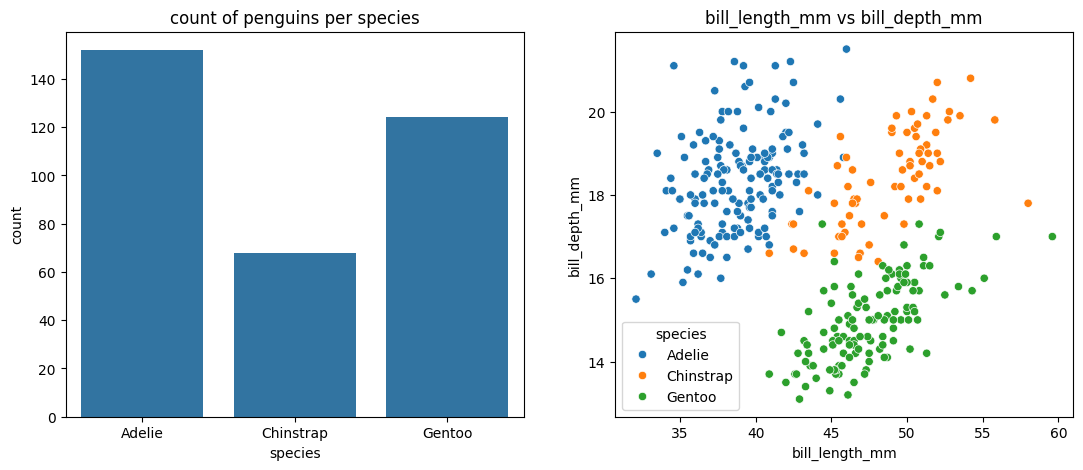

In [73]:
plt.figure(figsize = (13,5))

plt.subplot(1,2,1)
sns.countplot(x = 'species', data = df_clean)
plt.title('count of penguins per species')

plt.subplot(1,2,2)
sns.scatterplot(x = 'bill_length_mm', y = 'bill_depth_mm', hue = 'species', data = df_clean)
plt.title('bill_length_mm vs bill_depth_mm')
plt.show()

### Q11: Create a box plot of body_mass_g by species.

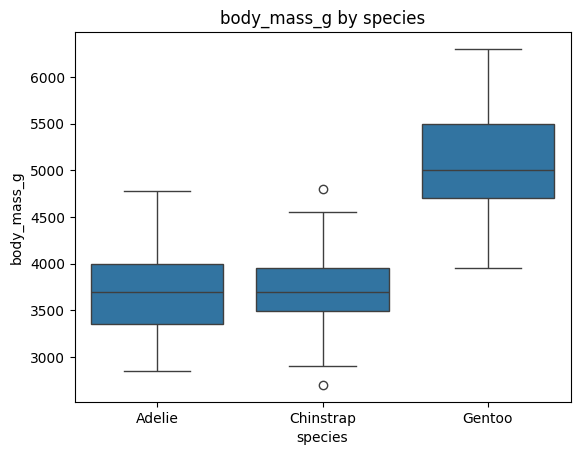

In [47]:
sns.boxplot(x = 'species', y = 'body_mass_g', data = df_clean)
plt.title('body_mass_g by species')
plt.show()

Interpretation
- Gentoo penguins are significantly heavier than the other two species;
- The Chinstrap species shows the presence of outliers both above and below the whiskers, suggesting a few individuals are unusually large or small for their group.
- The vertical spread (IQR) for Gentoo penguins is the largest, indicating that there is more variability in body mass within that species.

### Q12: Compute a correlation matrix for numeric features and visualize it as a heatmap.

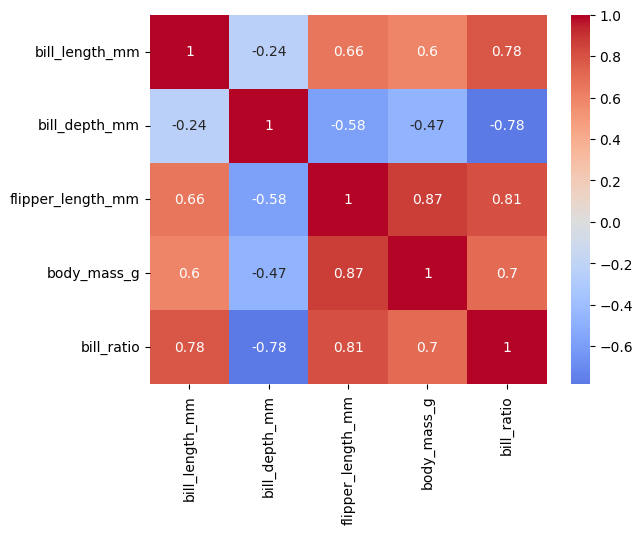

In [54]:
corr_matrix = df_clean.select_dtypes(include = ['number']).corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', center = 0)
plt.show()

## Part D: Machine Learning

### Q13: Define:
- target y = species
- features X = all other columns EXCEPT species
  
Then split into train/test using:
- test_size = 0.2
- random_state = 42
- stratify by y

In [55]:
y = df_clean['species']
X = df_clean.drop(columns=['species'])

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

### Q14: Preprocessing Data for ML Training

In [60]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer (
    transformers=[
        ("'num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
])

### Q15: Train models:

1. KNN Classifier with n_neighbors=5

In [61]:
knn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [64]:
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
print(knn_model.score(X_test, y_test))

0.9855072463768116


2. Logistic Regression (multiclass) with max_iter=2000

In [65]:
logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

In [67]:
logreg_model.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)
print(logreg_model.score(X_test, y_test))

1.0


### Q16: Conclude based on the accuracy results

Answer:

The KNN Clasifier model achieved an accuracy of 98.5% and The Logistic Regression model achieved an accuracy of 100%.
They both show high predictive power. But an accuracy of 100% for the Logistic Regression is suspicious, the model can be overfitted.